## Project Name: Heart Attack Risk Predictor

### In this project we will Make an app which will help us predict the risk of a Heart Attack a person have.
### We will do use various Algorithms to predict the result and see which one suits best and then we will use Auto ML Library EVAL ML to predict the results.

### We will do the following things:
- Data Analysis 
- Feature Engineering 
- Satandardization
- Model Building
- Predictions

### Let us import the necessary liabraries and read our DataSet

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Let us import our Data Set


In [2]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [3]:
df= pd.read_csv("heart.csv")

In [4]:
df= df.drop(['oldpeak','slp','thall'],axis=1)

In [5]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1


### Data Analysis

### Understanding our DataSet:

#### Age : Age of the patient

#### Sex : Sex of the patient

#### exang: exercise induced angina (1 = yes; 0 = no)

#### ca: number of major vessels (0-3)

#### cp : Chest Pain type chest pain type

- Value 0: typical angina
- Value 1: atypical angina
- Value 2: non-anginal pain
- Value 3: asymptomatic

#### trtbps : resting blood pressure (in mm Hg)

#### chol : cholestoral in mg/dl fetched via BMI sensor

#### fbs : (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)

#### rest_ecg : resting electrocardiographic results

- Value 0: normal
- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

#### thalach : maximum heart rate achieved

#### target : 0= less chance of heart attack 1= more chance of heart attack

In [6]:
df.shape

(303, 11)

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
caa         0
output      0
dtype: int64

#### As we can see there are no null values in our Data Set

In [8]:
df.corr()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.276326,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.118261,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.181053,0.433798
trtbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.101389,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.070511,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.137979,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.072042,0.137230
thalachh,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.213177,0.421741
exng,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.115739,-0.436757
caa,0.276326,0.118261,-0.181053,0.101389,0.070511,0.137979,-0.072042,-0.213177,0.115739,1.000000,-0.391724


<Axes: >

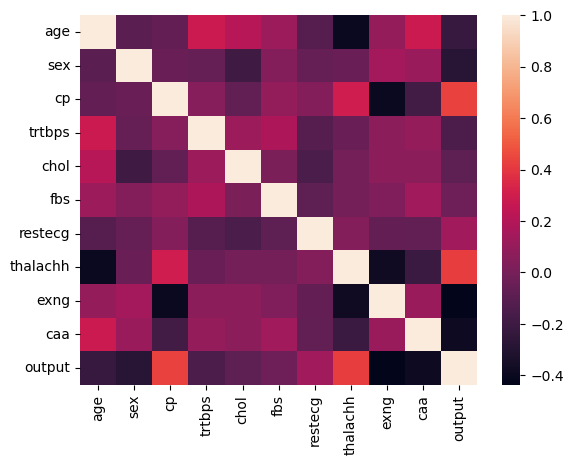

In [9]:
sns.heatmap(df.corr())

#### As we can see our variables are not highly correlated to each other 

#### We will do Uni and Bi variate analysis on our Features

<Axes: title={'center': 'Age of Patients'}, xlabel='Age', ylabel='count'>

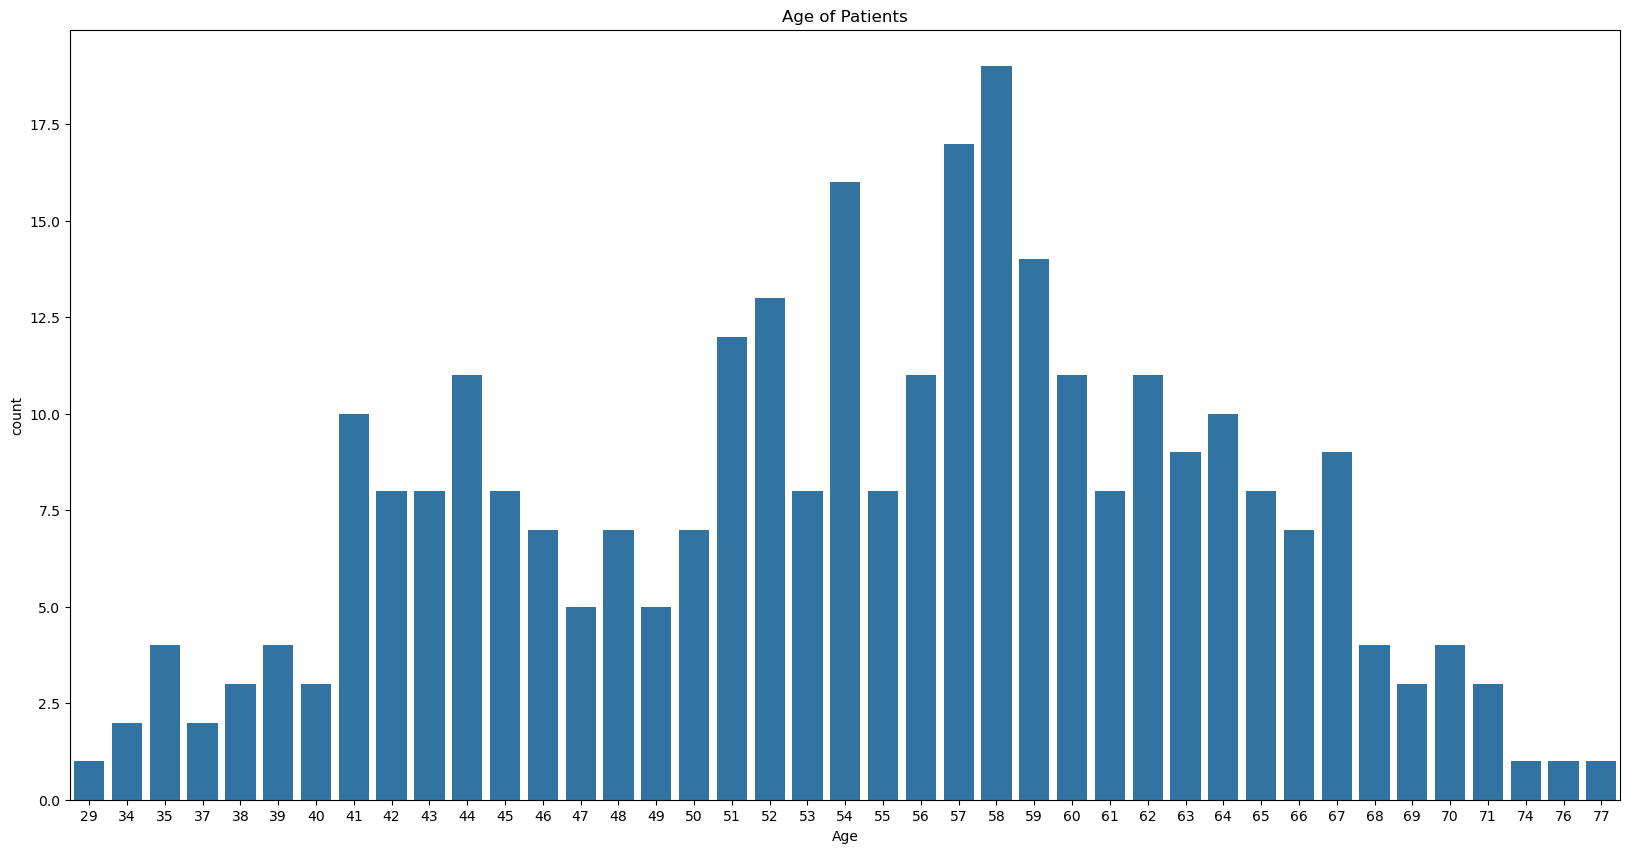

In [10]:

plt.figure(figsize=(20, 10))
plt.title("Age of Patients")
plt.xlabel("Age")
sns.countplot(x='age',data=df)

#### As we can see the Patients are of Age Group 51-67years in majority

<Axes: title={'center': 'Sex of Patients,0=Female and 1=Male'}, xlabel='sex', ylabel='count'>

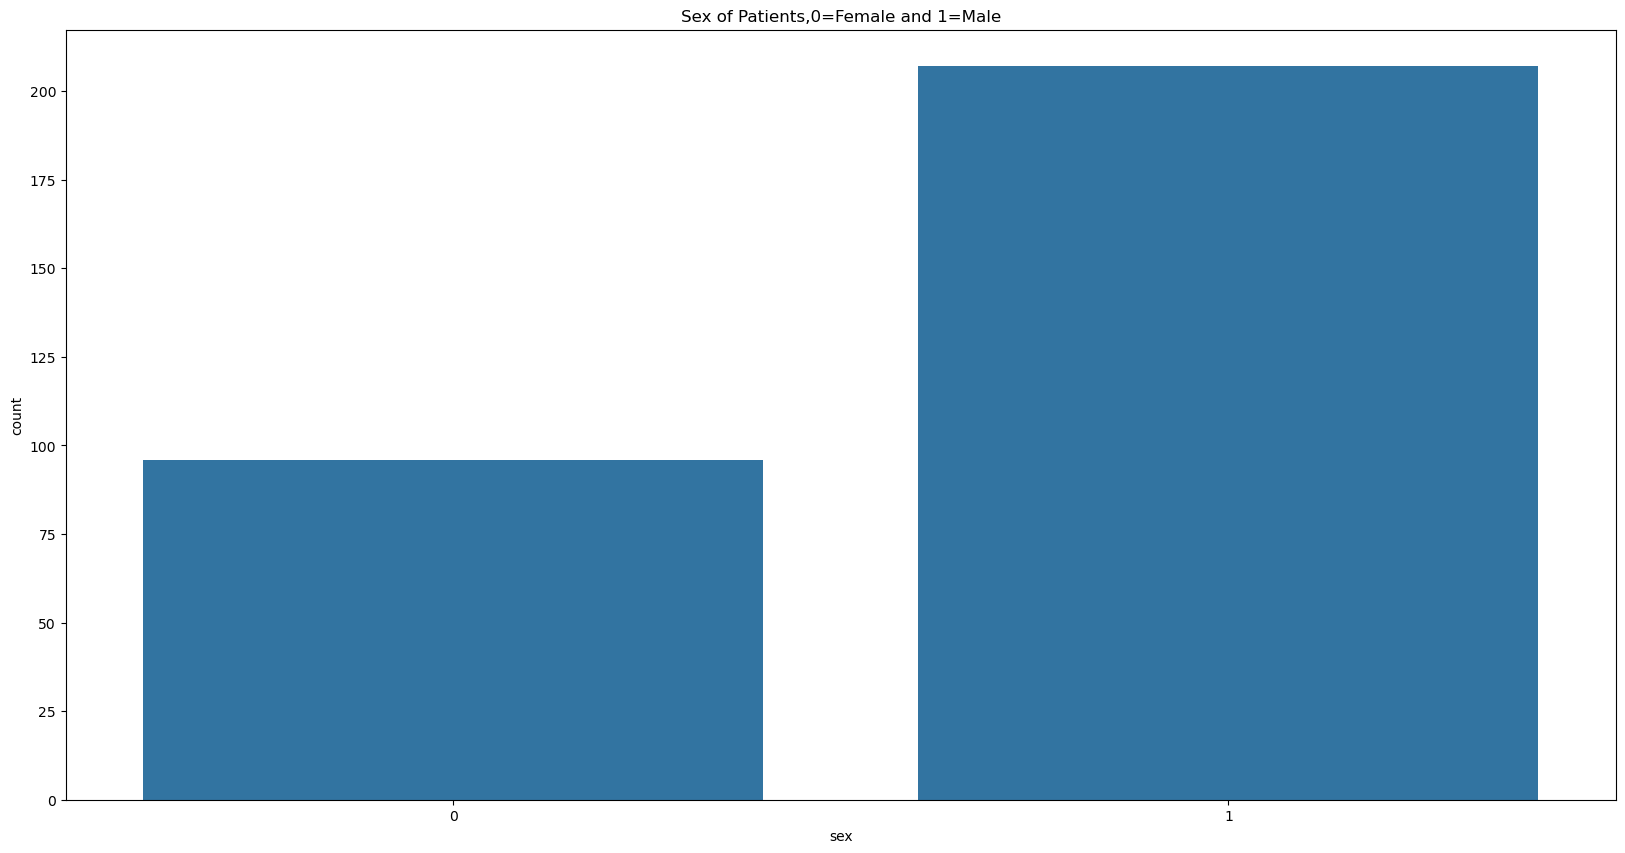

In [11]:
plt.figure(figsize=(20, 10))
plt.title("Sex of Patients,0=Female and 1=Male")

sns.countplot(x='sex',data=df)

In [12]:
cp_data = df['cp'].value_counts().reset_index()
cp_data.columns = ['cp', 'count']
cp_data['cp'] = cp_data['cp'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'non-anginal',
    3: 'asymptomatic'
})

C:\Users\SATYAJIT NAYAK\AppData\Local\Temp\ipykernel_14896\1181146000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cp_data['cp'], y=cp_data['count'], palette=colors)


<Axes: title={'center': 'Chest Pain of Patients'}, xlabel='cp', ylabel='count'>

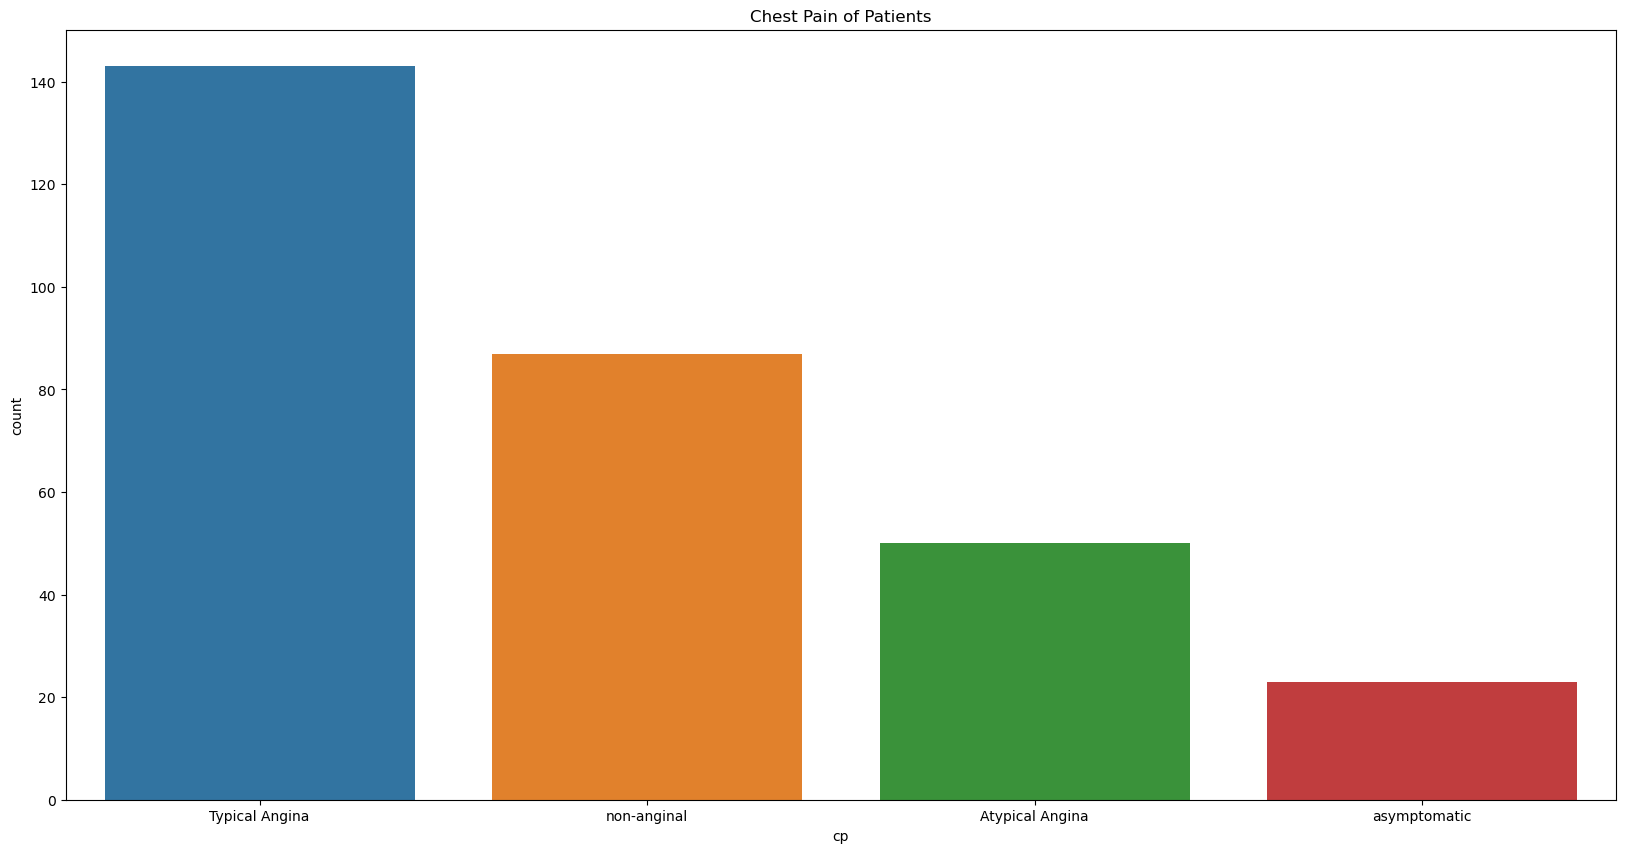

In [13]:
plt.figure(figsize=(20, 10))
plt.title("Chest Pain of Patients")
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.barplot(x=cp_data['cp'], y=cp_data['count'], palette=colors)

#### We have seen how the the Chest Pain Category is distributed

In [14]:
ecg_data= df['restecg'].value_counts().reset_index()
ecg_data.columns = ['index', 'count']
ecg_data['index'][0]= 'normal'
ecg_data['index'][1]= 'having ST-T wave abnormality'
ecg_data['index'][2]= 'showing probable or definite left ventricular hypertrophy by Estes'

ecg_data

C:\Users\SATYAJIT NAYAK\AppData\Local\Temp\ipykernel_14896\599870643.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ecg_data['index'][0]= 'normal'
C:\Users\SATYAJIT NAYAK\AppData\Local\Temp\ipykernel_14896\599870643.py:3: FutureWarning:

,index,count
0,normal,152
1,having ST-T wave abnormality,147
2,showing probable or definite left ventricular ...,4


C:\Users\SATYAJIT NAYAK\AppData\Local\Temp\ipykernel_14896\231497657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='index', y='count', data=ecg_data,palette='Set1')


<Axes: title={'center': 'ECG data of Patients'}, xlabel='index', ylabel='count'>

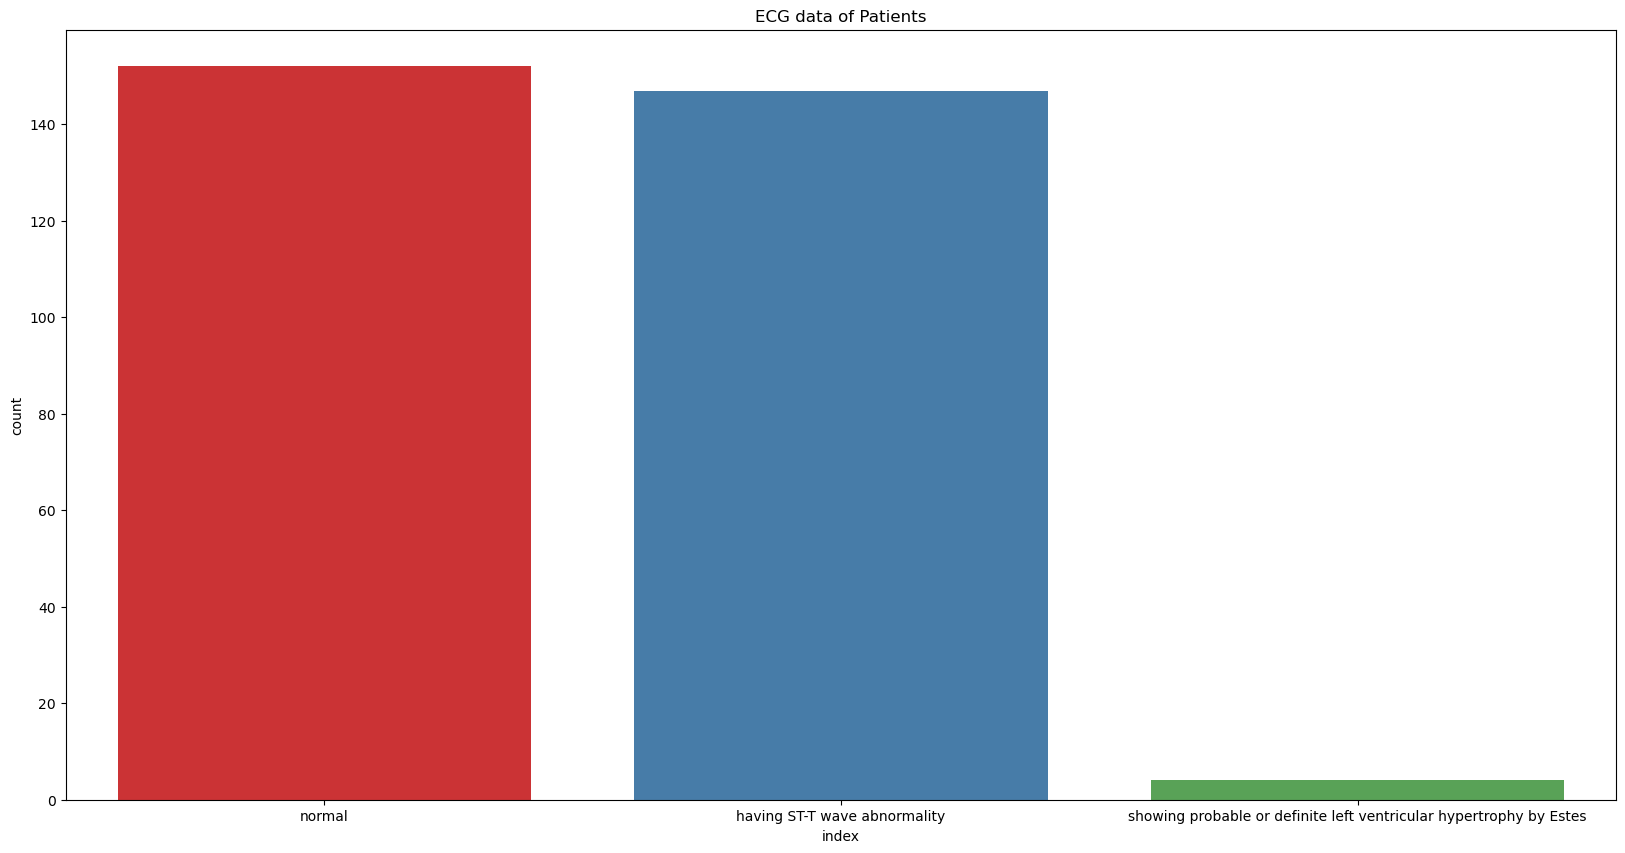

In [15]:
plt.figure(figsize=(20, 10))
plt.title("ECG data of Patients")

sns.barplot(x='index', y='count', data=ecg_data,palette='Set1')

#### This is our ECG Data 

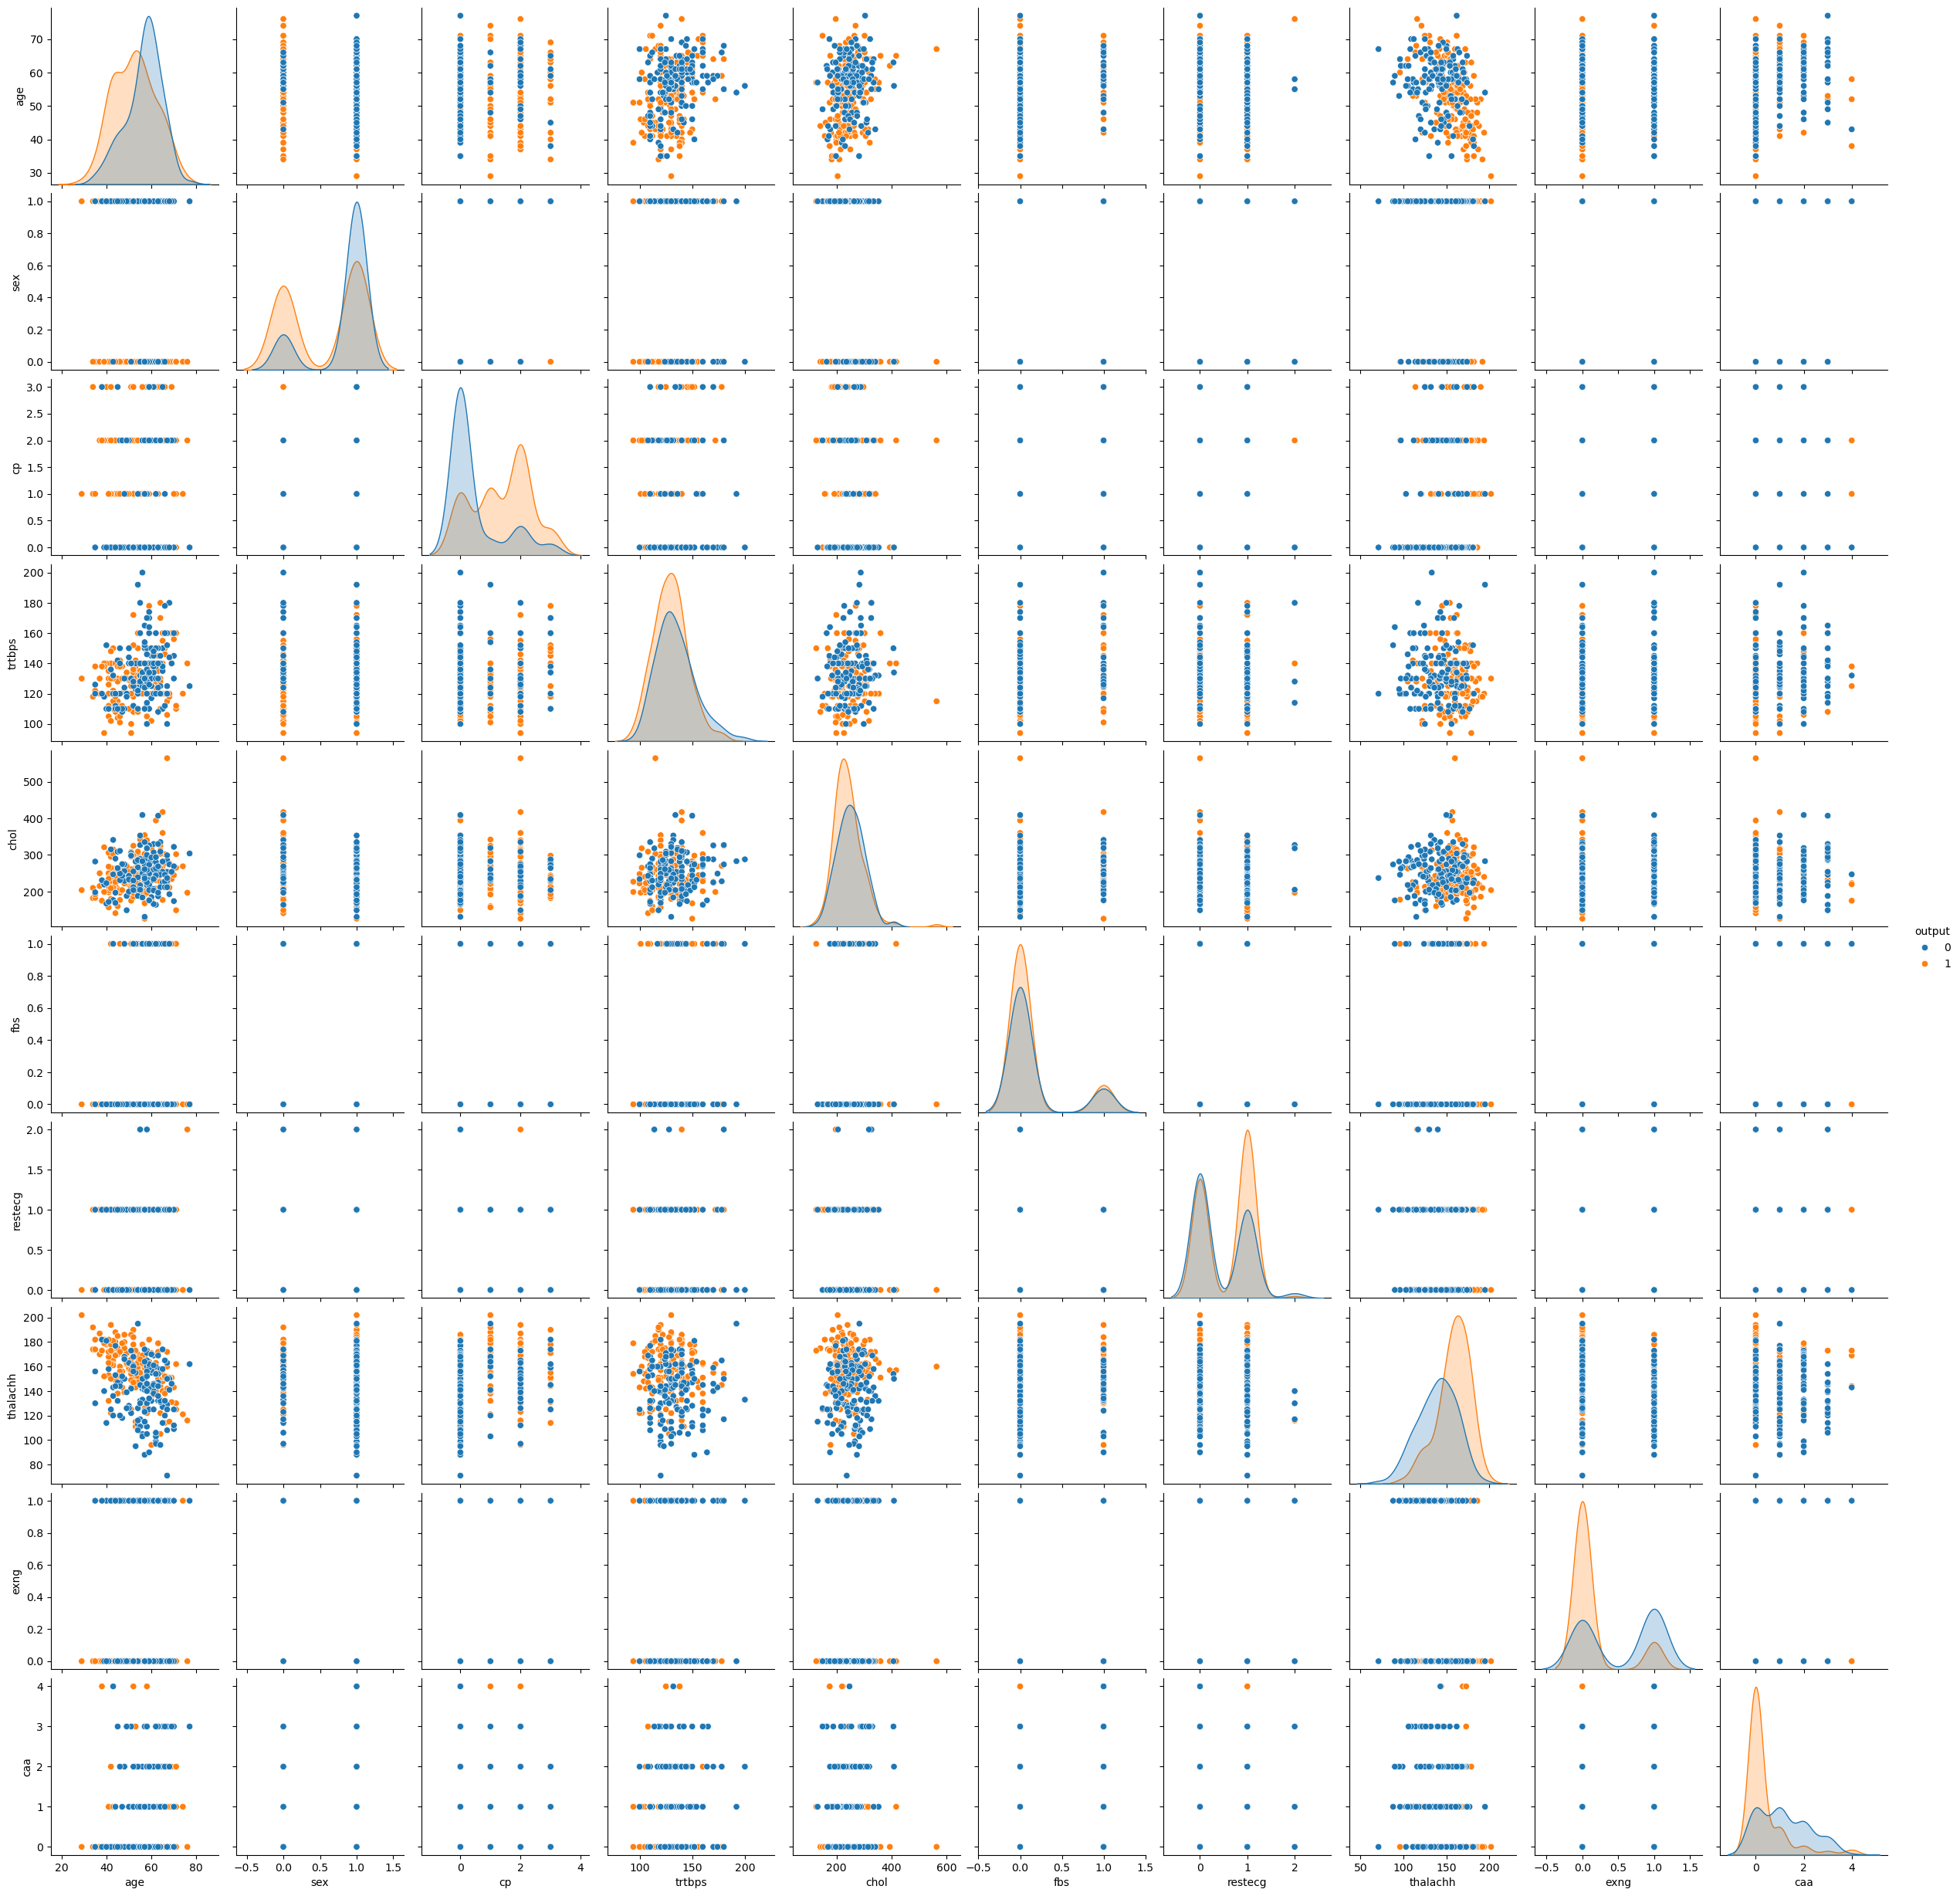

In [16]:
sns.pairplot(df,hue='output')

### Let us see for our Continuous Variable

Text(0.5, 0, 'Maximum Heart Rate Achieved (bpm)')

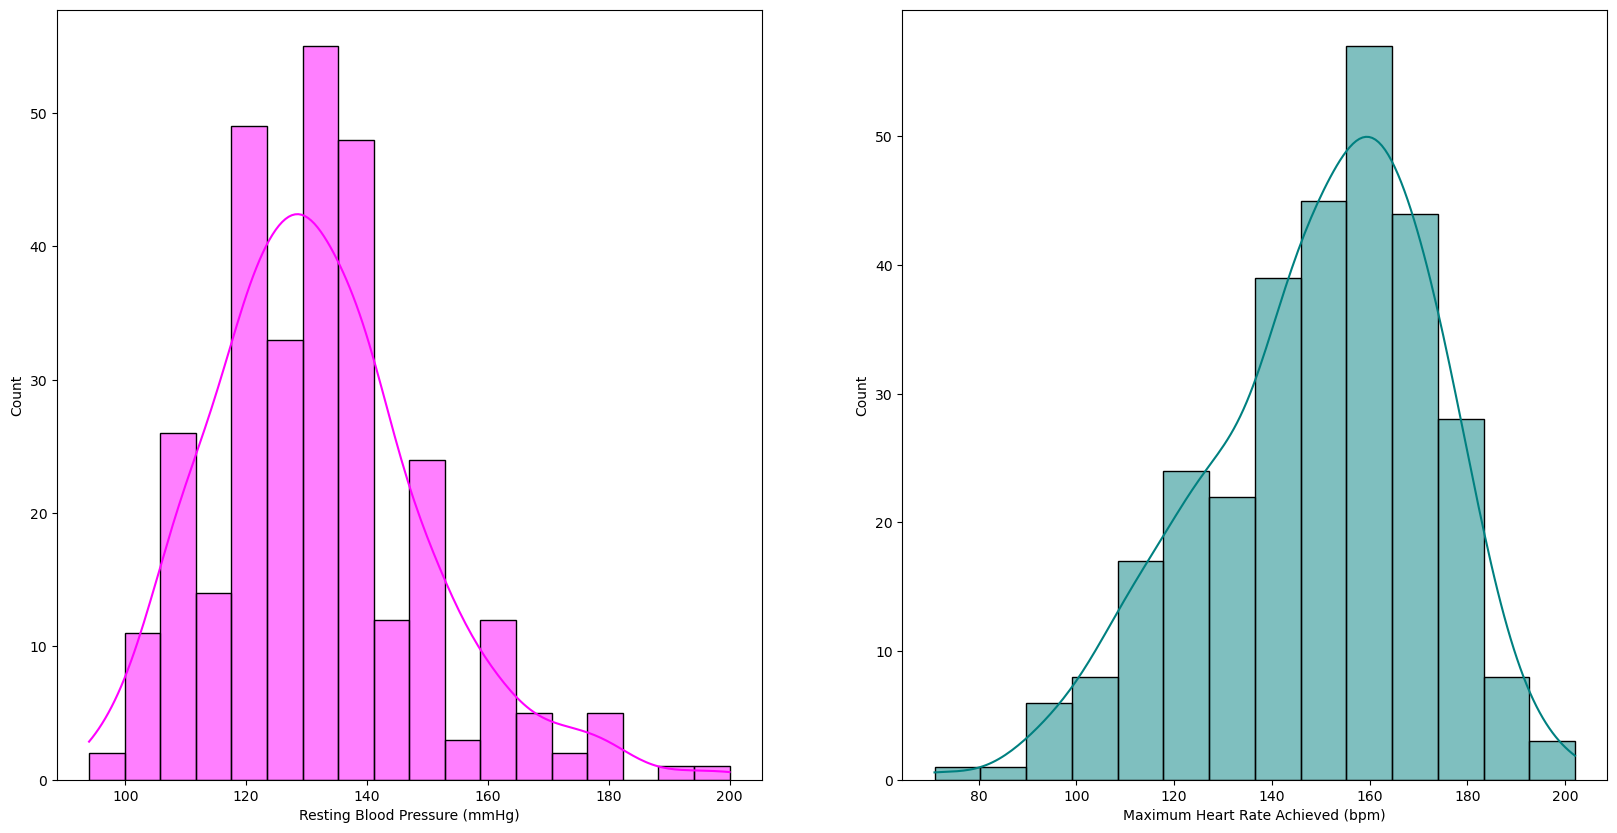

In [17]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.histplot(df['trtbps'], kde=True, color = 'magenta')
plt.xlabel("Resting Blood Pressure (mmHg)")
plt.subplot(1,2,2)
sns.histplot(df['thalachh'], kde=True, color = 'teal')
plt.xlabel("Maximum Heart Rate Achieved (bpm)")

Text(0.5, 0, 'Cholestrol')

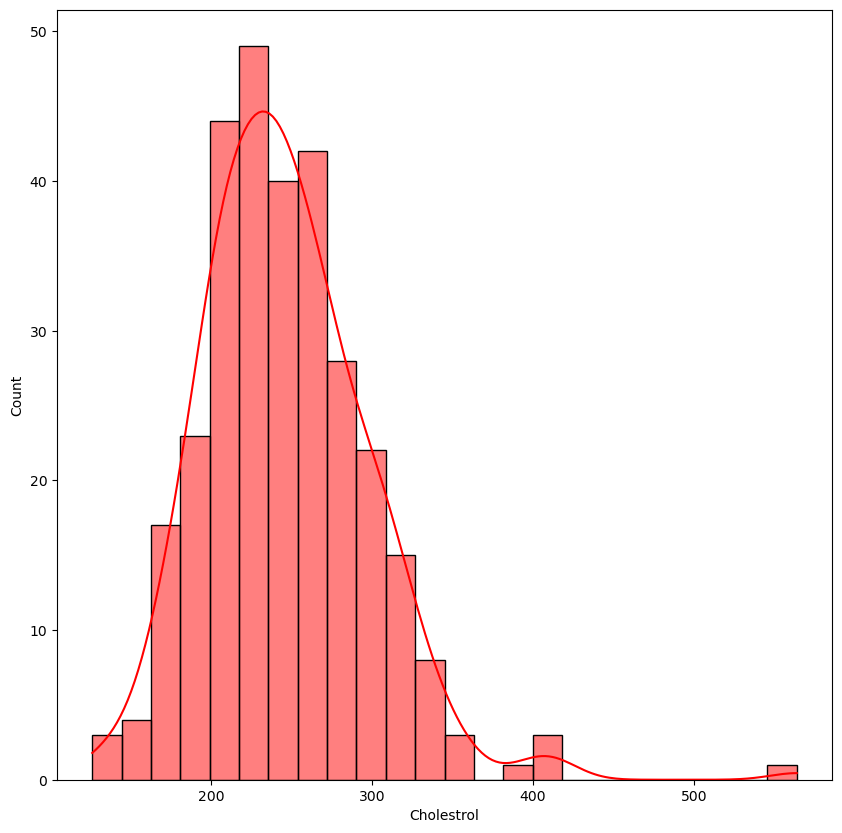

In [18]:
plt.figure(figsize=(10,10))
sns.histplot(df['chol'], kde=True, color = 'red')
plt.xlabel("Cholestrol")

#### We have done the Analysis of the data now let's have a look at out data

In [19]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1


### Let us do Standardisation

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [21]:
X = df.drop('output', axis=1)
y = df['output']


In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101, stratify=y
)


In [23]:
scale = StandardScaler()
x_train = pd.DataFrame(scale.fit_transform(x_train), columns=X.columns, index=x_train.index)
x_test = pd.DataFrame(scale.transform(x_test), columns=X.columns, index=x_test.index)


In [24]:
x_train.head()


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa
58,-2.216714,0.664964,1.904107,-0.761220,-1.174407,-0.390095,-1.024026,1.038513,-0.657596,-0.722629
217,1.013520,0.664964,-0.945333,-0.048731,1.588655,2.563480,-1.024026,-0.745574,1.520691,2.149822
81,-0.991453,0.664964,0.004480,-0.167480,1.177930,-0.390095,-1.024026,0.868600,-0.657596,-0.722629
247,1.347682,0.664964,0.004480,1.732489,0.020431,-0.390095,0.847469,-1.255313,1.520691,2.149822
182,0.790745,-1.503841,-0.945333,-0.048731,1.588655,-0.390095,-1.024026,0.826122,-0.657596,-0.722629


In [25]:
y_train.head()


58     1
217    0
81     1
247    0
182    0
Name: output, dtype: int64

### We can insert this data into our ML Models

### We will use the following models for our predictions :
- Logistic Regression
- Decision Tree
- Random Forest
- K Nearest Neighbour
- SVM

#### Then we will use the ensembling techniques

#### Let us split our data

In [26]:
x_train


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa
58,-2.216714,0.664964,1.904107,-0.761220,-1.174407,-0.390095,-1.024026,1.038513,-0.657596,-0.722629
217,1.013520,0.664964,-0.945333,-0.048731,1.588655,2.563480,-1.024026,-0.745574,1.520691,2.149822
81,-0.991453,0.664964,0.004480,-0.167480,1.177930,-0.390095,-1.024026,0.868600,-0.657596,-0.722629
247,1.347682,0.664964,0.004480,1.732489,0.020431,-0.390095,0.847469,-1.255313,1.520691,2.149822
182,0.790745,-1.503841,-0.945333,-0.048731,1.588655,-0.390095,-1.024026,0.826122,-0.657596,-0.722629
...,...,...,...,...,...,...,...,...,...,...
135,-0.545903,-1.503841,-0.945333,-0.048731,0.449825,-0.390095,0.847469,0.571252,-0.657596,-0.722629
83,-0.211741,0.664964,1.904107,1.257497,0.991236,2.563480,0.847469,1.208426,-0.657596,-0.722629
115,-1.882552,-1.503841,0.954294,-0.642472,-0.558319,-0.390095,0.847469,0.868600,-0.657596,-0.722629
164,-1.771165,0.664964,0.954294,0.426261,-1.305093,-0.390095,0.847469,0.996035,-0.657596,3.107306


In [27]:
y_train


58     1
217    0
81     1
247    0
182    0
      ..
135    1
83     1
115    1
164    1
249    0
Name: output, Length: 212, dtype: int64

In [28]:
x_test, y_test


(          age       sex        cp    trtbps      chol       fbs   restecg  \
 258  0.902133 -1.503841 -0.945333  1.138749 -0.016908 -0.390095  0.847469   
 298  0.345196 -1.503841 -0.945333  0.545009 -0.072916 -0.390095  0.847469   
 302  0.345196 -1.503841  0.004480 -0.048731 -0.166263 -0.390095 -1.024026   
 241  0.567971 -1.503841 -0.945333  2.563725  0.076439 -0.390095  0.847469   
 54   1.013520 -1.503841  0.954294  0.248139  0.132447 -0.390095 -1.024026   
 ..        ...       ...       ...       ...       ...       ...       ...   
 235 -0.323129  0.664964 -0.945333  0.545009  1.009906 -0.390095  0.847469   
 194  0.679358  0.664964  0.954294  0.545009 -1.118399 -0.390095 -1.024026   
 110  1.124908 -1.503841 -0.945333  2.919969  1.495308 -0.390095  0.847469   
 122 -1.437002 -1.503841  0.954294 -1.117464  0.431156 -0.390095 -1.024026   
 228  0.567971  0.664964  1.904107  2.326229  0.804543 -0.390095 -1.024026   
 
      thalachh      exng       caa  
 258  0.188948  1.520691 

### Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
# Target is already binary (0/1), so no label encoding is needed.


In [31]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)


In [32]:
y_train


58     1
217    0
81     1
247    0
182    0
      ..
135    1
83     1
115    1
164    1
249    0
Name: output, Length: 212, dtype: int64

In [33]:
logreg= LogisticRegression()

In [34]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [35]:
Y_pred1 = logreg.predict(x_test)
Y_pred1

array([1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1])

In [36]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [37]:
y_test = y_test.astype(int)
y_test


258    0
298    0
302    0
241    0
54     1
      ..
235    0
194    0
110    1
122    1
228    0
Name: output, Length: 91, dtype: int64

In [38]:
Y_pred1 = logreg.predict(x_test)
lr_conf_matrix = confusion_matrix(y_test, Y_pred1)
lr_acc_score = accuracy_score(y_test, Y_pred1)


In [39]:
lr_conf_matrix

array([[32,  9],
       [11, 39]])

In [40]:
print(lr_acc_score*100,"%")

78.02197802197803 %


#### As we see the Logistic Regression Model have a 85% accuracy

### Decision Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
tree= DecisionTreeClassifier()

In [43]:
tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [44]:
ypred2=tree.predict(x_test)

In [45]:
y_test = y_test.astype(int)
y_test


258    0
298    0
302    0
241    0
54     1
      ..
235    0
194    0
110    1
122    1
228    0
Name: output, Length: 91, dtype: int64

In [46]:
tree_conf_matrix = confusion_matrix(y_test, ypred2)
tree_acc_score = accuracy_score(y_test, ypred2)


In [47]:
tree_conf_matrix

array([[34,  7],
       [19, 31]])

In [48]:
print(tree_acc_score*100,"%")

71.42857142857143 %


#### As we see our Decision Tree Model does not perform well as it gives a score of only 69%

### Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf= RandomForestClassifier()

In [51]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
ypred3 = rf.predict(x_test)

In [53]:
rf_conf_matrix = confusion_matrix(y_test, ypred3)
rf_acc_score = accuracy_score(y_test, ypred3)


In [54]:
rf_conf_matrix

array([[31, 10],
       [11, 39]])

In [55]:
print(rf_acc_score*100,"%")

76.92307692307693 %


#### RF also gives us an accuracy of around 80%

### K Nearest Neighbour

#### We have to select what k we will use for the maximum accuracy
#### Let's write a function for it

In [56]:
from sklearn.neighbors import KNeighborsClassifier

In [57]:
error_rate= []
for i in range(1,40):
    knn= KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred= knn.predict(x_test)
    error_rate.append(np.mean(pred != y_test))

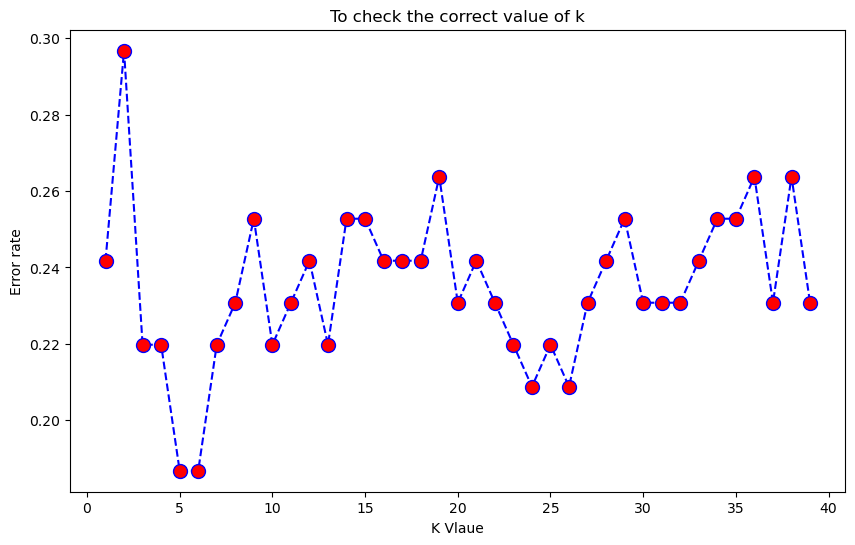

In [58]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.xlabel('K Vlaue')
plt.ylabel('Error rate')
plt.title('To check the correct value of k')
plt.show()

#### As we see from the graph we should select K= 12 as it gives the best error rate

In [59]:
knn= KNeighborsClassifier(n_neighbors=12)
knn.fit(x_train, y_train)
ypred4= knn.predict(x_test)


In [60]:
knn_conf_matrix = confusion_matrix(y_test, ypred4)
knn_acc_score = accuracy_score(y_test, ypred4)


In [61]:
knn_conf_matrix

array([[31, 10],
       [12, 38]])

In [62]:
print(knn_acc_score*100,"%")

75.82417582417582 %


#### As we see KNN gives us an accuracy of around 85% which is good

### Support Vector Machine(SVM)

In [63]:
from sklearn import svm

In [64]:
svm= svm.SVC()

In [65]:
svm.fit(x_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [66]:
ypred5= svm.predict(x_test)

In [67]:
svm_conf_matrix = confusion_matrix(y_test, ypred5)
svm_acc_score = accuracy_score(y_test, ypred5)


In [68]:
svm_conf_matrix

array([[32,  9],
       [ 9, 41]])

In [69]:
print(svm_acc_score*100,"%")

80.21978021978022 %


#### We get an accuracy of 80% in SVM

#### Let us see our model accuracy in Table form

In [70]:
model_acc= pd.DataFrame({'Model' : ['Logistic Regression','Decision Tree','Random Forest','K Nearest Neighbor','SVM'],'Accuracy' : [lr_acc_score*100,tree_acc_score*100,rf_acc_score*100,knn_acc_score*100,svm_acc_score*100]})

In [71]:
model_acc = model_acc.sort_values(by=['Accuracy'],ascending=False)

In [72]:
model_acc

,Model,Accuracy
4,SVM,80.219780
0,Logistic Regression,78.021978
2,Random Forest,76.923077
3,K Nearest Neighbor,75.824176
1,Decision Tree,71.428571


#### Let us use one more Techniques known as Adaboost, this is a Boosting technique which uses multiple models for better accuracy.

### Adaboost  Classifier

#### Let us first use some random parameters for training the model without Hypertuning.

In [73]:
from sklearn.ensemble import AdaBoostClassifier

In [74]:
# adab= AdaBoostClassifier(base_estimator=svm,n_estimators=100,algorithm='SAMME',learning_rate=0.01,random_state=0)

from sklearn.ensemble import AdaBoostClassifier

adab = AdaBoostClassifier(
    estimator=svm,
    n_estimators=100,
    algorithm="SAMME",
    learning_rate=0.01,
    random_state=0
)


In [75]:
adab.fit(x_train, y_train)


c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,estimator,SVC()
,n_estimators,100
,learning_rate,0.01
,algorithm,'SAMME'
,random_state,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True


In [76]:
ypred6=adab.predict(x_test)

In [77]:
adab_conf_matrix = confusion_matrix(y_test, ypred6)
adab_acc_score = accuracy_score(y_test, ypred6)


In [78]:
adab_conf_matrix

array([[ 0, 41],
       [ 0, 50]])

In [79]:
print(adab_acc_score*100,"%")

54.94505494505495 %


In [80]:
adab.score(x_train, y_train)


0.5424528301886793

In [81]:
adab.score(x_test, y_test)


0.5494505494505495

#### As we see our model has performed very poorly with just 50% accuracy 

#### We will use Grid Seach CV for HyperParameter Tuning

### Grid Search CV

#### Let us try Grid Search CV for our top 3 performing Algorithms for HyperParameter tuning

In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [83]:
lr = LogisticRegression(max_iter=5000)

In [84]:
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2', None],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.25, 0.5, 0.75]
    }
]

In [85]:
model_acc

,Model,Accuracy
4,SVM,80.219780
0,Logistic Regression,78.021978
2,Random Forest,76.923077
3,K Nearest Neighbor,75.824176
1,Decision Tree,71.428571


### Logistic Regression

In [86]:
# param_grid= {
    
#     'solver': ['newton-cg', 'lbfgs', 'liblinear','sag', 'saga'],
#     'penalty' : ['none', 'l1', 'l2', 'elasticnet'],
#     'C' : [100, 10, 1.0, 0.1, 0.01]
    
# }

In [87]:
grid = GridSearchCV(
    lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    error_score='raise'
)

In [88]:
# grid1= GridSearchCV(LogisticRegression(),param_grid)

In [89]:

grid.fit(x_train, y_train)

c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\SATYAJIT NAYAK\anaconda3\Lib\site-packages\sklearn\linear_model\_l

,estimator,LogisticRegre...max_iter=5000)
,param_grid,"[{'C': [0.01, 0.1, ...], 'penalty': ['l2', None], 'solver': ['lbfgs', 'newton-cg', ...]}, {'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, ...]"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,penalty,'l2'


In [90]:
# grid1.fit(x_train, y_train)

In [91]:
grid.best_params_

{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

#### Let us apply these para in our Model

In [92]:
logreg1= LogisticRegression(C=0.01,penalty='l2',solver='liblinear')

In [93]:
logreg1.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [94]:
logreg_pred= logreg1.predict(x_test)

In [95]:
logreg_pred_conf_matrix = confusion_matrix(y_test, logreg_pred)
logreg_pred_acc_score = accuracy_score(y_test, logreg_pred)


In [96]:
logreg_pred_conf_matrix

array([[34,  7],
       [12, 38]])

In [97]:
print(logreg_pred_acc_score*100,"%")

79.12087912087912 %


#### We got an accuracy of 81%

### KNN

In [98]:
n_neighbors = range(1, 21, 2)
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

In [99]:
grid = dict(n_neighbors=n_neighbors,weights=weights,metric=metric)

In [100]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [101]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

In [102]:
grid_search = GridSearchCV(estimator=knn, param_grid=grid, n_jobs=1, cv=cv, scoring='accuracy',error_score=0)

In [103]:
grid_search.fit(x_train, y_train)

,estimator,KNeighborsCla..._neighbors=12)
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': range(1, 21, 2), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,RepeatedStrat...andom_state=1)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,0
,return_train_score,False
,n_neighbors,11


In [104]:
grid_search.best_params_

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

#### Let's apply

In [105]:
knn= KNeighborsClassifier(n_neighbors=12,metric='manhattan',weights='distance')
knn.fit(x_train, y_train)
knn_pred= knn.predict(x_test)

In [106]:
knn_pred_conf_matrix = confusion_matrix(y_test, knn_pred)
knn_pred_acc_score = accuracy_score(y_test, knn_pred)


In [107]:
knn_pred_conf_matrix

array([[31, 10],
       [ 9, 41]])

In [108]:
print(knn_pred_acc_score*100,"%")

79.12087912087912 %


#### We have an Accuracy of 82.5%

### SVM

In [109]:

kernel = ['poly', 'rbf', 'sigmoid']
C = [50, 10, 1.0, 0.1, 0.01]
gamma = ['scale']

In [110]:
grid = dict(kernel=kernel,C=C,gamma=gamma)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=svm, param_grid=grid, n_jobs=1, cv=cv, scoring='accuracy',error_score=0)

In [111]:
grid_search.fit(x_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [50, 10, ...], 'gamma': ['scale'], 'kernel': ['poly', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,RepeatedStrat...andom_state=1)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,0
,return_train_score,False
,C,1.0


In [112]:
grid_search.best_params_

{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

#### Let us apply these

In [113]:
from sklearn.svm import SVC

In [114]:
svc= SVC(C= 0.1, gamma= 'scale',kernel= 'sigmoid')

In [115]:
svc.fit(x_train, y_train)

,C,0.1
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [116]:
svm_pred= svc.predict(x_test)

In [117]:
svm_pred_conf_matrix = confusion_matrix(y_test, svm_pred)
svm_pred_acc_score = accuracy_score(y_test, svm_pred)


In [118]:
svm_pred_conf_matrix

array([[33,  8],
       [ 9, 41]])

In [119]:
print(svm_pred_acc_score*100,"%")

81.31868131868131 %


#### Accuracy is 81%

## Final Verdict

#### After comparing all the models the best performing model is :
### Logistic Regression with no Hyperparameter tuning

In [120]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [121]:
Y_pred1

array([1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1])

In [122]:
lr_conf_matrix

array([[32,  9],
       [11, 39]])

In [123]:
print(lr_acc_score*100,"%")

78.02197802197803 %


#### Let us build a proper confusion matrix for our model

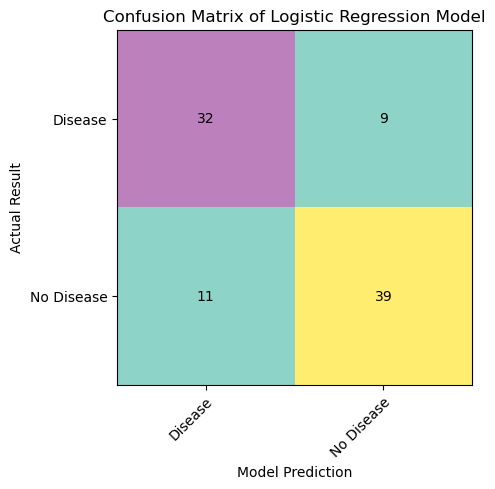

ACCURACY of our model is  78.02197802197803 %


In [124]:
# Confusion Matrix of  Model enlarged
options = ["Disease", 'No Disease']

fig, ax = plt.subplots()
im = ax.imshow(lr_conf_matrix, cmap= 'Set3', interpolation='nearest')

# We want to show all ticks...
ax.set_xticks(np.arange(len(options)))
ax.set_yticks(np.arange(len(options)))
# ... and label them with the respective list entries
ax.set_xticklabels(options)
ax.set_yticklabels(options)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(options)):
    for j in range(len(options)):
        text = ax.text(j, i, lr_conf_matrix[i, j],
                       ha="center", va="center", color="black")

ax.set_title("Confusion Matrix of Logistic Regression Model")
fig.tight_layout()
plt.xlabel('Model Prediction')
plt.ylabel('Actual Result')
plt.show()
print("ACCURACY of our model is ",lr_acc_score*100,"%")

## We have succesfully made our model which predicts weather a person is having a risk of Heart Disease or not with 85.7% accuracy